In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Customer Segmentation Project Started 🚀")

Customer Segmentation Project Started 🚀


In [1]:
import pandas as pd

df = pd.read_excel("../data/raw/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.shape 

(541909, 8)

In [3]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cust

In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [8]:
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [9]:
df['Country'].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [12]:
df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [13]:
df['Country'].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [14]:
df = df.dropna(subset=['CustomerID'])

In [15]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [16]:
df = df[df['Quantity'] > 0]

In [17]:
df = df[df['Quantity'] > 0]

In [18]:
df = df[df['UnitPrice'] > 0]

In [19]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [20]:
df.shape

(397884, 9)

In [21]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [22]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [23]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [24]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [25]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [26]:
rfm.head

<bound method NDFrame.head of             Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
...             ...        ...       ...
18280.0         278          1    180.60
18281.0         181          1     80.82
18282.0           8          2    178.05
18283.0           4         16   2094.88
18287.0          43          3   1837.28

[4338 rows x 3 columns]>

In [27]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [28]:
df[df['CustomerID'] == 12346]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6


In [29]:
df[df['CustomerID'] == 12346][['InvoiceNo','Description','Quantity','UnitPrice','TotalPrice']]

,InvoiceNo,Description,Quantity,UnitPrice,TotalPrice
61619,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.6


In [30]:
df[df['CustomerID'] == 12346]['InvoiceNo'].nunique()

1

In [31]:
df.sort_values('TotalPrice', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,4992.00
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-01-11 12:55:00,2.55,15749.0,United Kingdom,4921.50
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-04-18 13:20:00,2.40,15749.0,United Kingdom,4632.00


In [32]:
df['Description'].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1723
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1396
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
POSTAGE                               1099
PACK OF 72 RETROSPOT CAKE CASES       1068
Name: count, dtype: int64

In [33]:
rfm.sort_values('Frequency', ascending=False).head(10)

,Recency,Frequency,Monetary
CustomerID,,,
12748.0,1,209,33719.73
14911.0,1,201,143825.06
17841.0,2,124,40991.57
13089.0,3,97,58825.83
14606.0,1,93,12156.65
15311.0,1,91,60767.90
12971.0,4,86,11189.91
14646.0,2,73,280206.02
16029.0,39,63,81024.84


In [34]:
rfm.sort_values('Recency').head(10)

,Recency,Frequency,Monetary
CustomerID,,,
17364.0,1,11,4481.18
12433.0,1,7,13375.87
13599.0,1,21,5153.67
13536.0,1,7,3448.29
16933.0,1,2,563.23
17581.0,1,25,11045.04
15898.0,1,5,1388.88
16892.0,1,5,525.54
17644.0,1,11,2895.64


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
import os
print(os.getcwd())

c:\Users\USer\Desktop\customer-segmentation-analysis\notebooks


In [17]:
import os
print(os.listdir())

['analysis.ipynb']


In [1]:
import os
print(os.listdir())

['analysis.ipynb', 'Online Retail.xlsx']


In [2]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [7]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [8]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [9]:
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [10]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [11]:
rfm.shape

(4372, 3)

In [12]:
rfm.sort_values('Monetary', ascending=False).head(10)

,Recency,Frequency,Monetary
CustomerID,,,
14646.0,2,77,279489.02
18102.0,1,62,256438.49
17450.0,8,55,187482.17
14911.0,1,248,132572.62
12415.0,24,26,123725.45
14156.0,10,66,113384.14
17511.0,3,46,88125.38
16684.0,4,31,65892.08
13694.0,4,60,62653.10


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

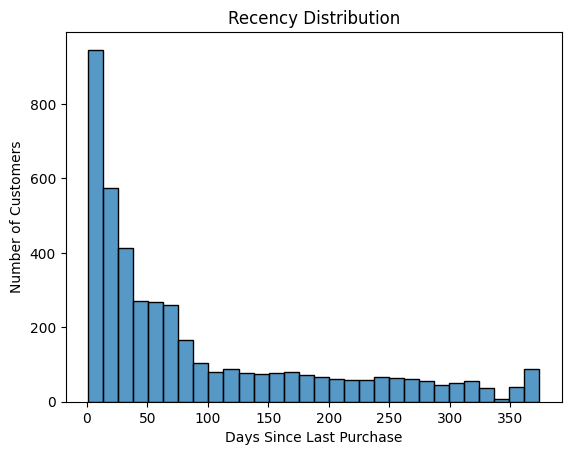

In [14]:
plt.figure()
sns.histplot(rfm['Recency'], bins=30)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.show()

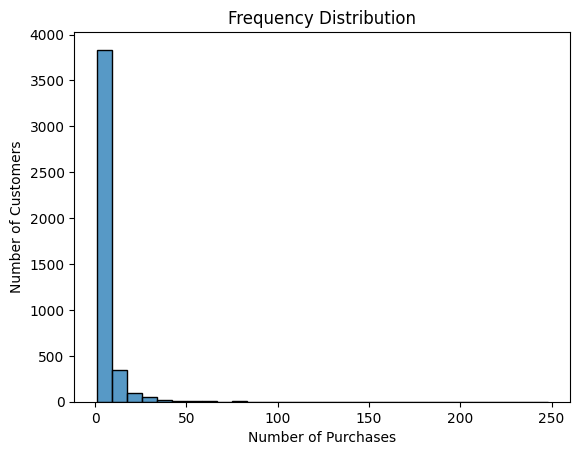

In [15]:
plt.figure()
sns.histplot(rfm['Frequency'], bins=30)
plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

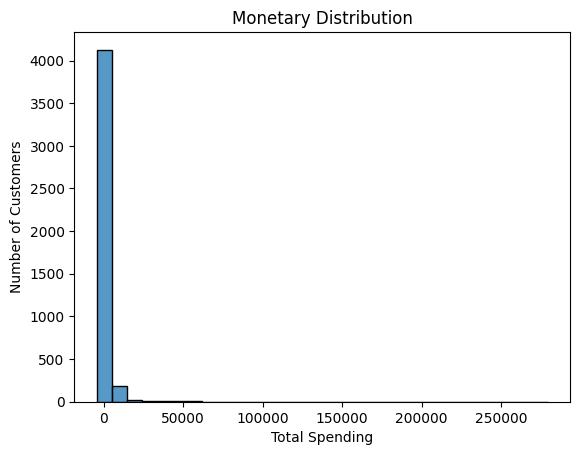

In [16]:
plt.figure()
sns.histplot(rfm['Monetary'], bins=30)
plt.title("Monetary Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()

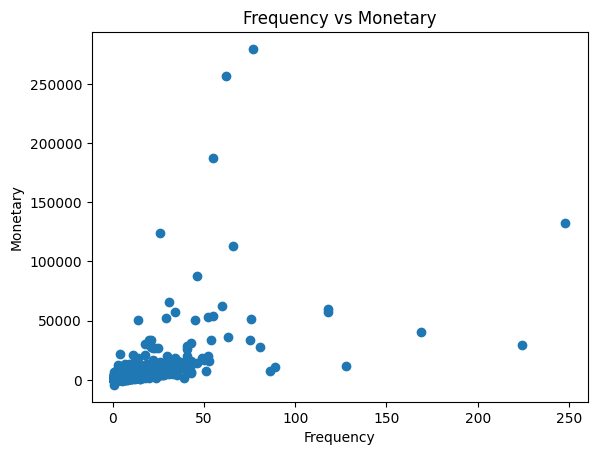

In [17]:
plt.figure()
plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Frequency vs Monetary")
plt.show()

In [18]:
import numpy as np

rfm_log = np.log1p(rfm)

c:\Users\USer\Desktop\customer-segmentation-analysis\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


In [19]:
rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,1.098612,0.000000
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


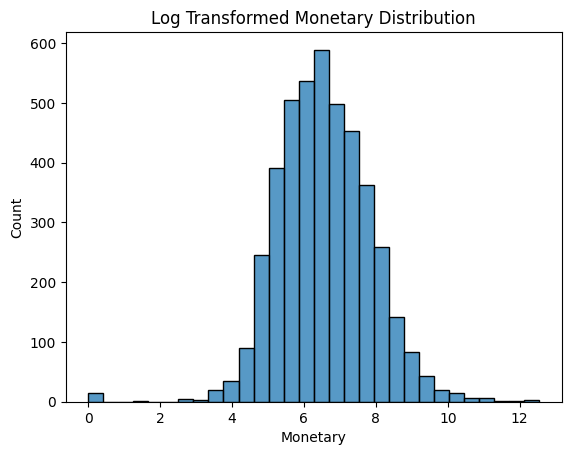

In [20]:
plt.figure()
sns.histplot(rfm_log['Monetary'], bins=30)
plt.title("Log Transformed Monetary Distribution")
plt.show()

In [21]:
rfm_log = np.log1p(rfm)

c:\Users\USer\Desktop\customer-segmentation-analysis\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [23]:
rfm_scaled[:5]

array([[ 1.45560892, -0.46749327, -5.05301076],
       [-1.97486147,  0.86440534,  1.40176449],
       [ 0.38857348,  0.22617276,  0.72738794],
       [-0.58762392, -1.01808698,  0.71017392],
       [ 1.41892494, -1.01808698, -0.56777429]])

In [26]:
rfm.isna().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [27]:
rfm[rfm['Monetary'] < 0]

,Recency,Frequency,Monetary
CustomerID,,,
12503.0,338,1,-1.126000e+03
12505.0,301,1,-4.500000e+00
12605.0,365,1,-7.500000e+00
12666.0,359,1,-2.274400e+02
12870.0,366,1,-1.490000e+01
12943.0,301,1,-3.750000e+00
13154.0,144,1,-6.118600e+02
13672.0,301,6,-7.146000e+01
13693.0,325,2,-3.200000e+01


In [28]:
rfm = rfm[rfm['Monetary'] > 0]

In [29]:
rfm.shape

(4322, 3)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [32]:
import numpy as np

rfm_log = np.log1p(rfm)

rfm_log.isna().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [33]:
np.isinf(rfm_log).sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [34]:
rfm_log = rfm_log.replace([np.inf, -np.inf], np.nan)
rfm_log = rfm_log.dropna()

In [35]:
rfm_log.isna().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [37]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

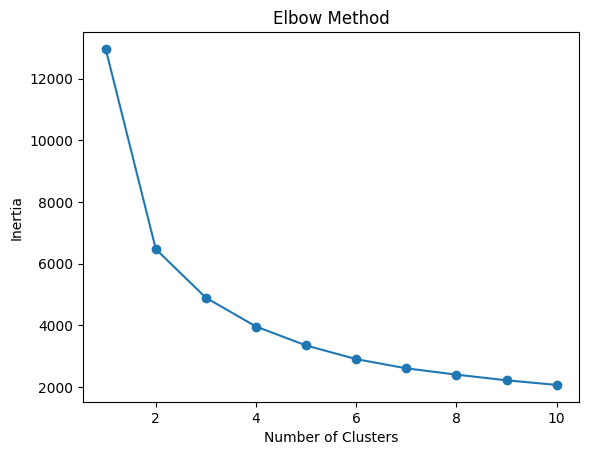

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [39]:
np.isnan(rfm_scaled).sum()

np.int64(0)

In [40]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [41]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,1
12350.0,310,1,334.40,0
12352.0,36,11,1545.41,2


In [42]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,180.463759,1.515971,353.621119
1,18.483645,2.315421,528.807535
2,64.514912,5.176316,1703.481468
3,10.459885,16.846705,7654.687178


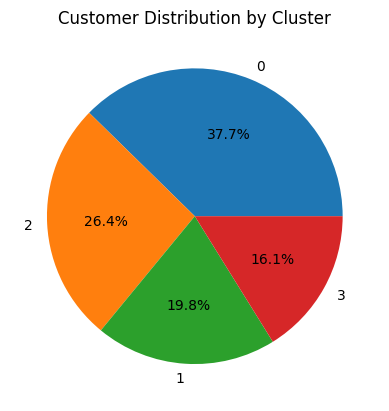

In [43]:
rfm['Cluster'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title="Customer Distribution by Cluster"
)

plt.ylabel("")
plt.show()

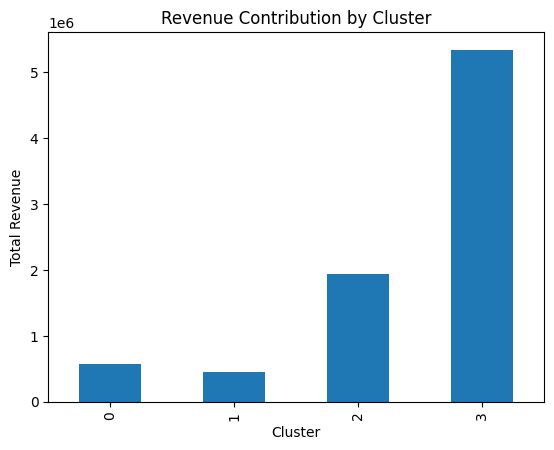

In [44]:
revenue_cluster = rfm.groupby('Cluster')['Monetary'].sum()

revenue_cluster.plot(
    kind='bar',
    title="Revenue Contribution by Cluster"
)

plt.ylabel("Total Revenue")
plt.show()

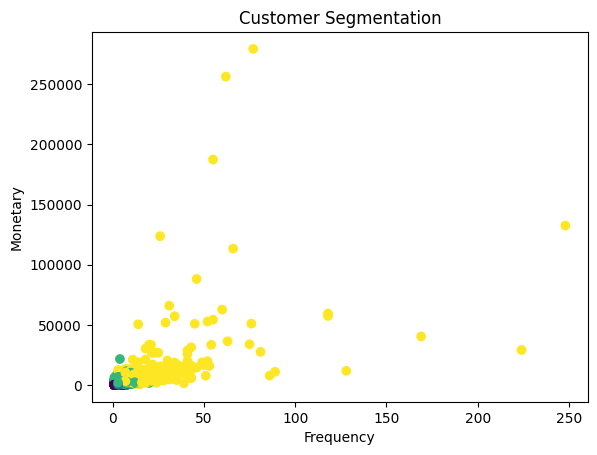

In [45]:
plt.figure()

plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'])

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segmentation")

plt.show()

In [46]:
!pip install plotly

In [2]:
!pip install plotly

In [2]:
import sys
!{sys.executable} -m pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.9 MB 1.4 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.9 MB 1.1 MB/s eta 0:00:09
   ---- ----------------------------------- 1.0/9.9 MB 1.1 MB/s eta 0:00:09
   ----- ---------------------------------- 1.3/9.9 MB 1.0 MB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.9 MB 1.0 MB/s eta 0:00:09
   ------- -------------------------------- 1.8/9.9 MB 1.0 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.9 MB 1.0 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/9.9 MB 1.0 MB/s eta 0:00:08
   -------- ----------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import plotly.graph_objects as go

In [2]:
import plotly.express as px

fig = px.scatter(x=[1,2,3], y=[3,1,6])
fig.show()